# Carregamento do DataSet

In [1]:
%reload_ext autoreload
%autoreload 2

from variables import filenames, features, target
from load_dataset import load
from pre_processing import apply, ReplaceInfWithNan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = load(filenames)
df = apply(df)
df.head()

Quantidade de duplicatas antes de remover:  308381


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# Preprocessamento

In [3]:
# Remove valores nulos e infinitos da base
df.replace([np.inf, -np.inf], np.nan, inplace=True)

linhas_antes = len(df)
valores_nulos_antes = int(df.isna().sum().sum())

df.dropna(inplace=True)

print(f"Linhas antes: {linhas_antes}")
print(f"Valores nulos/inf convertidos para NaN: {valores_nulos_antes}")
print(f"Linhas após limpeza: {len(df)}")
print(f"Total de NaN restantes: {int(df.isna().sum().sum())}")

Linhas antes: 2522362
Valores nulos/inf convertidos para NaN: 3128
Linhas após limpeza: 2520798
Total de NaN restantes: 0


# Analise do Dataset

In [4]:
df.drop(columns=["Destination Port"], inplace=True)
df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,109,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,52,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,34,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
df = df[df['Label'].isin(['BENIGN','DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye'])]
df['Label'].value_counts()

Label
BENIGN              2095057
DoS Hulk             172846
DoS GoldenEye         10286
DoS slowloris          5385
DoS Slowhttptest       5228
Name: count, dtype: int64

In [6]:
df['Label'].value_counts()

Label
BENIGN              2095057
DoS Hulk             172846
DoS GoldenEye         10286
DoS slowloris          5385
DoS Slowhttptest       5228
Name: count, dtype: int64

In [7]:
# Variância de todas as colunas numéricas
cols = df.columns.drop("Label", errors="ignore")
variancias = df[cols].select_dtypes(include=np.number).var().sort_values()

# Lista das colunas com variância 0 (ou muito próxima de 0)
colunas_variancia_zero = variancias[np.isclose(variancias, 0.0)].index.tolist()

print("\nColunas com variância igual a 0 (ou muito próxima de 0):")
print(colunas_variancia_zero)

# Remove essas colunas do DataFrame
df = df.drop(columns=colunas_variancia_zero, errors="ignore")
print(f"\nTotal de colunas removidas: {len(colunas_variancia_zero)}")


Colunas com variância igual a 0 (ou muito próxima de 0):
['Fwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Fwd Avg Packets/Bulk', 'Bwd Avg Bytes/Bulk', 'Fwd Avg Bulk Rate', 'Bwd URG Flags', 'Bwd PSH Flags']

Total de colunas removidas: 8


In [8]:
col1, col2 = "Fwd Header Length", "Fwd Header Length.1"

if col1 not in df.columns or col2 not in df.columns:
    print(f"Coluna ausente. Disponíveis? {col1 in df.columns=}, {col2 in df.columns=}")
else:
    iguais = df[col1].equals(df[col2])  # compara considerando NaN na mesma posição como igual
    print(f"As colunas '{col1}' e '{col2}' são totalmente iguais? {iguais}")

    mask_diff = ~(df[col1].eq(df[col2]) | (df[col1].isna() & df[col2].isna()))
    qtd_diff = int(mask_diff.sum())
    total = len(df)

    print(f"Total de linhas: {total}")
    print(f"Linhas diferentes: {qtd_diff} ({(qtd_diff/total)*100:.6f}%)")

    if qtd_diff > 0:
        print("\nExemplos de diferenças:")
        display(df.loc[mask_diff, [col1, col2]].head(10))

As colunas 'Fwd Header Length' e 'Fwd Header Length.1' são totalmente iguais? True
Total de linhas: 2288802
Linhas diferentes: 0 (0.000000%)


In [9]:
#Remover a coluna "Fwd Header Length.1" por ser idêntica à "Fwd Header Length"
if "Fwd Header Length.1" in df.columns:
    df.drop(columns=["Fwd Header Length.1"], inplace=True)
    print("Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.")

Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.


In [10]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["Class"] = label_encoder.fit_transform(df["Label"].astype(str))

mapa_classes = pd.DataFrame({
    "Label": label_encoder.classes_,
    "Class": range(len(label_encoder.classes_))
})

display(mapa_classes)

,Label,Class
0,BENIGN,0
1,DoS GoldenEye,1
2,DoS Hulk,2
3,DoS Slowhttptest,3
4,DoS slowloris,4


In [11]:
df.drop(columns=["Label"], inplace=True)

## Separação Treino/Teste


In [12]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Class'])

## Balanceamento

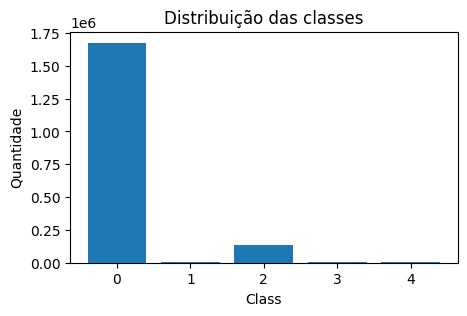

In [13]:
def plot_class_distribution(df, class_col="Class"):
    counts = df[class_col].value_counts().sort_index()
    plt.figure(figsize=(5,3))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("Distribuição das classes")
    plt.xlabel("Class")
    plt.ylabel("Quantidade")
    plt.show()
plot_class_distribution(df_train)

In [14]:
df_train['Class'].value_counts()

Class
0    1676045
2     138277
1       8229
4       4308
3       4182
Name: count, dtype: int64

In [16]:
from imblearn.under_sampling import RandomUnderSampler

#rus = RandomUnderSampler(
#    sampling_strategy={
#        0: min(100000, df_train["Class"].value_counts()[0]),  # Benign
#        2: min(100000, df_train["Class"].value_counts()[2]),  # DoS Hulk
#        1: df_train["Class"].value_counts()[1],               # DoS GoldenEye
#        3: df_train["Class"].value_counts()[3],               # DoS Slowhttptest
#        4: df_train["Class"].value_counts()[4],               # DoS Slowloris
#    },
#    random_state=42
#)

rus = RandomUnderSampler(
    sampling_strategy={
        0: min(200000, df_train["Class"].value_counts()[0]),  # Benign
        2: min(100000, df_train["Class"].value_counts()[2]),  # DoS Hulk
        1: df_train["Class"].value_counts()[1],               # DoS GoldenEye
        3: df_train["Class"].value_counts()[3],               # DoS Slowhttptest
        4: df_train["Class"].value_counts()[4],               # DoS Slowloris
    },
    random_state=42
)


df_train_bal, _ = rus.fit_resample(
    df_train,
    df_train["Class"]
)

In [15]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from collections import Counter

# undersampling leve
rus = RandomUnderSampler(
    sampling_strategy={
        0: 200000,
        2: 138277,
        1: 8229,
        3: 4182,
        4: 4308
    },
    random_state=42
)

df_train_bal_under, _ = rus.fit_resample(df_train, df_train["Class"])

# oversampling das menores
smote = SMOTE(
    sampling_strategy={
        1: 30000,
        3: 30000,
        4: 30000
    },
    random_state=42
)

df_train_bal_over, _ = smote.fit_resample(df_train_bal_under, df_train_bal_under["Class"])

print(Counter(df_train_bal_over["Class"]))

Counter({0: 200000, 2: 138277, 1: 30000, 3: 30000, 4: 30000})


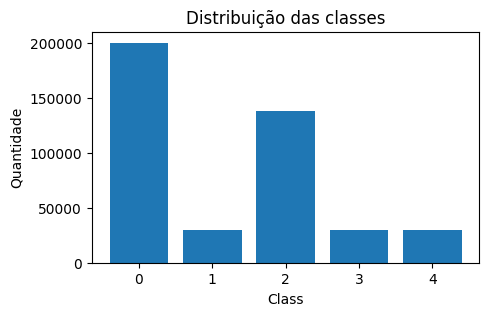

In [16]:
plot_class_distribution(df_train_bal_over)

In [17]:
df_train_bal_over['Class'].value_counts()

Class
0    200000
2    138277
1     30000
3     30000
4     30000
Name: count, dtype: int64

# Treinamento

In [18]:
X_train = df_train.drop(columns=["Class"])
X_train_bal = df_train_bal_over.drop(columns=["Class"])

y_train = df_train["Class"]
Y_train_bal = df_train_bal_over["Class"]

X_test = df_test.drop(columns=["Class"])
y_test = df_test["Class"]

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from pre_processing import ReplaceInfWithNan

model = Pipeline(steps=[
    ("replace_inf", ReplaceInfWithNan()),
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(random_state=42, n_estimators=100, warm_start=True))
])

In [23]:
from sklearn.ensemble import RandomForestClassifier
import time

randomForest = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1, class_weight='balanced')
start = time.time()
randomForest.fit(X_train, y_train)
end = time.time()
print(f"Treinamento concluído em {end - start:.2f} segundos")

Treinamento concluído em 110.39 segundos


In [19]:
from sklearn.ensemble import RandomForestClassifier
import time

randomForest_bal = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
start = time.time()
randomForest_bal.fit(X_train_bal, Y_train_bal)
end = time.time()
print(f"Treinamento concluído em {end - start:.2f} segundos")

Treinamento concluído em 23.27 segundos


## Salvamento do Modelo e Scaler

In [48]:
import joblib
import os 

#Cria a pasta modelo caso não exista
os.makedirs("modelo", exist_ok=True)

# Salvar o modelo treinado
joblib.dump(randomForest, "./modelo/random_forest.joblib")
joblib.dump(randomForest_bal, "./modelo/random_forest_balanced.joblib")

# Salvar o LabelEncoder
joblib.dump(label_encoder, "modelo/label_encoder.joblib")

# Salvar o scaler
#joblib.dump(scaler, "modelo/minmax_scaler.joblib")

['modelo/label_encoder.joblib']

## Avaliação do Modelo

In [26]:
y_predict = randomForest.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

def show_classification_metrics(y_true, y_pred):
    print("Acurácia:", accuracy_score(y_true, y_pred))
    print("Precisão:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred))

    # Matriz de confusão gráfica
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title('Matriz de Confusão')
    plt.show()

def plot_roc_auc(y_true, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR (False Positive Rate)')
    plt.ylabel('TPR (True Positive Rate)')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.show()
    print(f'AUC: {auc:.4f}')

Acurácia: 0.999383958004286
Precisão: 0.9993900019767027
Recall: 0.999383958004286
F1 Score: 0.999385576127227

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       1.00      1.00      1.00      2057
           2       1.00      1.00      1.00     34569
           3       0.95      0.99      0.97      1046
           4       1.00      0.99      1.00      1077

    accuracy                           1.00    457761
   macro avg       0.99      1.00      0.99    457761
weighted avg       1.00      1.00      1.00    457761



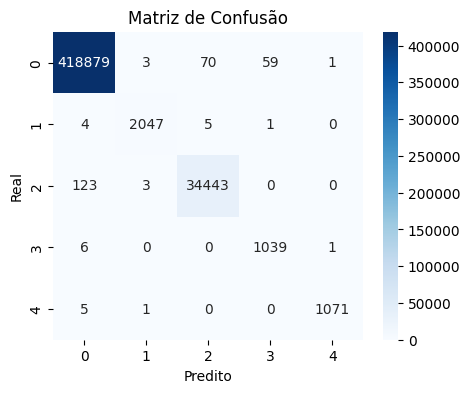

In [27]:
show_classification_metrics(y_test, y_predict)

In [89]:
import pandas as pd

importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importances.head(20)

,feature,importance
8,Bwd Packet Length Std,0.122453
27,Avg Bwd Segment Size,0.088406
7,Bwd Packet Length Mean,0.077646
24,Packet Length Variance,0.060904
6,Bwd Packet Length Max,0.056326
23,Packet Length Std,0.053515
26,Average Packet Size,0.050130
31,Subflow Bwd Bytes,0.045475
22,Packet Length Mean,0.041818
21,Max Packet Length,0.034924


In [74]:
importances.to_csv("feature_importances.csv", index=False)